# Regime Beta Backtest

?? 12?? ?? ??? ???? ??? ????, ?? ??? Gaussian HMM?? `bull / bear`
2? ???? ??? ???? ??? ?? ??? ??? ???? ?-?? ??? ????.

? ???? ?? ?? ???? ??? ??.

- ?? ??? `?? ???? + ? ???` 2?? HMM?? ??
- HMM? ?? ?? ????? ??? `expanding window` ???? ? ?? ???
- ??? ??? ?? 12?? rolling regression? ??? ???/?? ??? ??
- ?? ??? `ThreadPoolExecutor` ?? ?? ???? ??
- bull??? ?? ?? ??, bear??? ?? ?? ??? ?
- bull probability? ??? ????? ?? ?? ?? ??


In [1]:
import math
import os
import warnings
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
DATA_ROOT = Path("../../00_input").resolve()
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"DATA_ROOT does not exist: {DATA_ROOT}. "
        "Run this notebook from the 08_regime_beta folder."
    )

START_DATE = "2000-12-31"
BETA_WINDOW = 12
HMM_MIN_TRAIN = 36
HMM_ROLLING_WINDOW = None
N_JOBS = max(1, (os.cpu_count() or 4) - 1)
BETA_BLOCK_SIZE = 200
SELECTION_PCT = 0.20
AMBIGUOUS_BAND = (0.45, 0.55)
PARTIAL_INVEST = 0.50
TRANSACTION_COST_BPS = 20
WEIGHTING = "equal"  # "equal" or "value"
SAMPLE_N_COLS = None  # 빠른 드라이런이 필요하면 정수로 설정

print("DATA_ROOT:", DATA_ROOT)
print("N_JOBS:", N_JOBS)


DATA_ROOT: C:\Users\XH58\Desktop\Quantifi\02_2026-1\02_메인 세션\00_input
N_JOBS: 5


In [3]:
def maybe_trim_columns(df: pd.DataFrame, sample_n_cols: int | None = None) -> pd.DataFrame:
    if sample_n_cols is None:
        return df
    keep = list(df.columns[:sample_n_cols])
    return df.loc[:, keep]


def load_wide_csv(name: str, sample_n_cols: int | None = None) -> pd.DataFrame:
    df = pd.read_csv(DATA_ROOT / name, parse_dates=["Date"])
    df = (
        df.dropna(subset=["Date"])
        .sort_values("Date")
        .drop_duplicates("Date")
        .set_index("Date")
    )
    return maybe_trim_columns(df, sample_n_cols)


def month_end_last(df: pd.DataFrame) -> pd.DataFrame:
    return df.resample("ME").last()


def monthly_returns(prices: pd.DataFrame | pd.Series) -> pd.DataFrame | pd.Series:
    return prices.sort_index().pct_change(fill_method=None)


def monthly_rf_from_factors(factors_daily: pd.DataFrame) -> pd.Series:
    rf_level = month_end_last(factors_daily[["RF"]]).squeeze().astype(float)
    rf_ret = (1 + rf_level.div(100)).pow(1 / 12) - 1
    return rf_ret.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def align_monthly_frames(*frames: pd.DataFrame | pd.Series, start_date: str | None = None):
    common_index = frames[0].index
    for frame in frames[1:]:
        common_index = common_index.intersection(frame.index)
    common_index = common_index.sort_values()
    if start_date is not None:
        common_index = common_index[common_index >= pd.Timestamp(start_date)]
    aligned = []
    for frame in frames:
        aligned.append(frame.reindex(common_index))
    return aligned


def beta_block(stock_block: pd.DataFrame, market_excess: pd.Series, window: int, min_periods: int) -> pd.DataFrame:
    x = market_excess.astype(float)
    y = stock_block.astype(float)

    mean_x = x.rolling(window=window, min_periods=min_periods).mean()
    var_x = x.rolling(window=window, min_periods=min_periods).var()
    mean_y = y.rolling(window=window, min_periods=min_periods).mean()
    mean_xy = y.mul(x, axis=0).rolling(window=window, min_periods=min_periods).mean()
    cov_xy = mean_xy.sub(mean_y.mul(mean_x, axis=0), axis=0)

    return cov_xy.div(var_x.replace(0, np.nan), axis=0)


def rolling_beta_parallel(
    stock_excess: pd.DataFrame,
    market_excess: pd.Series,
    window: int = 12,
    min_periods: int | None = None,
    n_jobs: int = -1,
    block_size: int = 200,
) -> pd.DataFrame:
    min_periods = window if min_periods is None else min_periods
    columns = list(stock_excess.columns)
    blocks = [columns[i : i + block_size] for i in range(0, len(columns), block_size)]

    if len(blocks) == 1 or n_jobs == 1:
        return beta_block(stock_excess.loc[:, columns], market_excess, window, min_periods)

    max_workers = len(blocks) if n_jobs in (-1, None) else max(1, n_jobs)
    max_workers = min(max_workers, len(blocks))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        parts = list(
            executor.map(
                lambda block: beta_block(stock_excess.loc[:, block], market_excess, window, min_periods),
                blocks,
            )
        )
    return pd.concat(parts, axis=1).reindex(columns=columns)


def infer_hmm_regimes(
    features: pd.DataFrame,
    min_train: int = 36,
    rolling_window: int | None = None,
    random_seed: int = 42,
) -> pd.DataFrame:
    features = features.dropna().copy()
    out = pd.DataFrame(index=features.index, columns=["bull_prob", "regime"], dtype=object)

    for end_ix in range(min_train - 1, len(features)):
        if rolling_window is None:
            train = features.iloc[: end_ix + 1]
        else:
            start_ix = max(0, end_ix + 1 - rolling_window)
            train = features.iloc[start_ix : end_ix + 1]

        if len(train) < min_train:
            continue

        scaler = StandardScaler()
        x_train = scaler.fit_transform(train.values)

        fitted = False
        for seed in (random_seed, random_seed + 7, random_seed + 21):
            try:
                model = GaussianHMM(
                    n_components=2,
                    covariance_type="full",
                    n_iter=200,
                    random_state=seed,
                )
                model.fit(x_train)
                probs = model.predict_proba(x_train)[-1]
                bull_state = int(np.argmax(model.means_[:, 0]))
                bull_prob = float(probs[bull_state])
                out.loc[train.index[-1], "bull_prob"] = bull_prob
                out.loc[train.index[-1], "regime"] = "bull" if bull_prob >= 0.5 else "bear"
                fitted = True
                break
            except Exception:
                continue

        if not fitted:
            out.loc[train.index[-1], "bull_prob"] = np.nan
            out.loc[train.index[-1], "regime"] = np.nan

    out["bull_prob"] = pd.to_numeric(out["bull_prob"], errors="coerce")
    return out


def infer_vol_regime(market_vol: pd.Series, lookback: int = 12) -> pd.DataFrame:
    vol = market_vol.dropna().copy()
    vol_cut = vol.rolling(lookback, min_periods=lookback).median()
    bull_prob = pd.Series(np.where(vol <= vol_cut, 0.7, 0.3), index=vol.index)
    regime = pd.Series(np.where(vol <= vol_cut, "bull", "bear"), index=vol.index)
    return pd.DataFrame({"bull_prob": bull_prob, "regime": regime}, index=vol.index)


def compute_turnover(current_weights: pd.Series, previous_weights: pd.Series) -> float:
    idx = current_weights.index.union(previous_weights.index)
    current = current_weights.reindex(idx, fill_value=0.0)
    previous = previous_weights.reindex(idx, fill_value=0.0)
    return float((current - previous).abs().sum())


def backtest_regime_beta(
    beta_signal: pd.DataFrame,
    fwd_returns: pd.DataFrame,
    regime_df: pd.DataFrame,
    eligible_mask: pd.DataFrame,
    rf_monthly: pd.Series,
    market_caps: pd.DataFrame | None = None,
    selection_pct: float = 0.20,
    ambiguous_band: tuple[float, float] = (0.45, 0.55),
    partial_invest: float = 0.50,
    transaction_cost_bps: float = 20,
    weighting: str = "equal",
    bull_side: str = "high",
    bear_side: str = "low",
) -> tuple[pd.DataFrame, dict[pd.Timestamp, list[str]]]:
    common_index = (
        beta_signal.index
        .intersection(fwd_returns.index)
        .intersection(regime_df.index)
        .intersection(eligible_mask.index)
        .intersection(rf_monthly.index)
        .sort_values()
    )

    net_returns = pd.Series(index=common_index, dtype=float)
    gross_returns = pd.Series(index=common_index, dtype=float)
    invested_weight = pd.Series(index=common_index, dtype=float)
    turnover_series = pd.Series(index=common_index, dtype=float)
    picks = {}
    previous_weights = pd.Series(dtype=float)

    def side_for_regime(regime_name: str) -> str:
        return bull_side if regime_name == "bull" else bear_side

    for dt in common_index:
        regime = regime_df.at[dt, "regime"] if dt in regime_df.index else np.nan
        bull_prob = regime_df.at[dt, "bull_prob"] if dt in regime_df.index else np.nan
        signal = beta_signal.loc[dt].where(eligible_mask.loc[dt].fillna(False)).dropna()

        if signal.empty or pd.isna(bull_prob) or regime not in {"bull", "bear"}:
            weights = pd.Series(dtype=float)
        else:
            side = side_for_regime(regime)
            threshold = signal.quantile(1 - selection_pct if side == "high" else selection_pct)
            chosen = signal[signal >= threshold] if side == "high" else signal[signal <= threshold]

            if chosen.empty:
                weights = pd.Series(dtype=float)
            else:
                invest_share = partial_invest if ambiguous_band[0] <= bull_prob <= ambiguous_band[1] else 1.0
                if weighting == "value" and market_caps is not None:
                    cap_slice = market_caps.loc[dt, chosen.index].clip(lower=0)
                    cap_slice = cap_slice[cap_slice > 0]
                    if cap_slice.empty:
                        weights = pd.Series(invest_share / len(chosen), index=chosen.index)
                    else:
                        weights = invest_share * cap_slice.div(cap_slice.sum())
                else:
                    weights = pd.Series(invest_share / len(chosen), index=chosen.index)

        current_turnover = compute_turnover(weights, previous_weights)
        realized = fwd_returns.loc[dt].reindex(weights.index).fillna(0.0)
        gross = float((weights * realized).sum() + (1 - weights.sum()) * rf_monthly.loc[dt])
        trading_cost = current_turnover * (transaction_cost_bps / 10000)

        gross_returns.loc[dt] = gross
        net_returns.loc[dt] = gross - trading_cost
        invested_weight.loc[dt] = weights.sum()
        turnover_series.loc[dt] = current_turnover
        picks[dt] = list(weights.index)
        previous_weights = weights

    return (
        pd.DataFrame(
            {
                "gross_return": gross_returns,
                "net_return": net_returns,
                "invested_weight": invested_weight,
                "turnover": turnover_series,
            }
        ),
        picks,
    )


def performance_stats(returns: pd.Series, rf_monthly: pd.Series | None = None, periods_per_year: int = 12) -> pd.Series:
    returns = returns.dropna()
    if returns.empty:
        return pd.Series(dtype=float)

    wealth = (1 + returns).cumprod()
    total_return = wealth.iloc[-1] - 1
    ann_return = wealth.iloc[-1] ** (periods_per_year / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    rf_aligned = rf_monthly.reindex(returns.index).fillna(0.0) if rf_monthly is not None else pd.Series(0.0, index=returns.index)
    excess = returns - rf_aligned
    sharpe = np.sqrt(periods_per_year) * excess.mean() / returns.std() if returns.std() > 0 else np.nan
    running_max = wealth.cummax()
    mdd = (wealth / running_max - 1).min()

    return pd.Series(
        {
            "cumulative_return": total_return,
            "annual_return": ann_return,
            "annual_volatility": ann_vol,
            "sharpe": sharpe,
            "mdd": mdd,
        }
    )


def summarize_by_regime(strategy_returns: pd.Series, regime_df: pd.DataFrame, rf_monthly: pd.Series) -> pd.DataFrame:
    common_index = strategy_returns.index.intersection(regime_df.index)
    rows = {}
    for regime_name in ["bull", "bear"]:
        mask = regime_df.loc[common_index, "regime"] == regime_name
        rows[regime_name] = performance_stats(strategy_returns.loc[common_index][mask], rf_monthly)
    return pd.DataFrame(rows)


In [4]:
factors_daily = load_wide_csv("Factors.csv")
prices_daily = load_wide_csv("KOSPI_KOSDAQ_adj_close.csv", sample_n_cols=SAMPLE_N_COLS)
market_caps = month_end_last(load_wide_csv("KOSPI_KOSDAQ_mkt_cap.csv", sample_n_cols=SAMPLE_N_COLS))
trading_value = month_end_last(load_wide_csv("KOSPI_KOSDAQ_trading_value_60.csv", sample_n_cols=SAMPLE_N_COLS))

prices_monthly = month_end_last(prices_daily)
stock_returns = monthly_returns(prices_monthly)

market_levels = factors_daily[["KOSPI"]].astype(float)
market_returns_daily = monthly_returns(market_levels).squeeze()
market_returns_monthly = monthly_returns(month_end_last(market_levels)).squeeze()
market_vol_monthly = (
    market_returns_daily.groupby(pd.Grouper(freq="ME")).std()
    * np.sqrt(market_returns_daily.groupby(pd.Grouper(freq="ME")).count())
)
rf_monthly = monthly_rf_from_factors(factors_daily)

(
    stock_returns,
    market_returns_monthly,
    market_vol_monthly,
    rf_monthly,
    market_caps,
    trading_value,
) = align_monthly_frames(
    stock_returns,
    market_returns_monthly,
    market_vol_monthly,
    rf_monthly,
    market_caps,
    trading_value,
    start_date=START_DATE,
)

stock_excess = stock_returns.sub(rf_monthly, axis=0)
market_excess = market_returns_monthly - rf_monthly

print("monthly stock panel:", stock_returns.shape)
print("monthly market observations:", len(market_returns_monthly))


monthly stock panel: (304, 3948)
monthly market observations: 304


In [5]:
beta_12m = rolling_beta_parallel(
    stock_excess=stock_excess,
    market_excess=market_excess,
    window=BETA_WINDOW,
    n_jobs=N_JOBS,
    block_size=BETA_BLOCK_SIZE,
)

liquidity_rank = trading_value.rank(axis=1, pct=True, method="average")
size_rank = market_caps.rank(axis=1, pct=True, method="average")
eligible_mask = (liquidity_rank >= 0.20) & (size_rank >= 0.20) & beta_12m.notna()

beta_12m.iloc[-5:, :5]


,삼성전자,SK하이닉스,현대차,LG에너지솔루션,삼성바이오로직스
Date,,,,,
2025-11-30,1.0358,2.4555,1.1974,1.4447,0.8470
2025-12-31,1.0726,2.6456,1.2719,1.3792,0.8777
2026-01-31,1.1333,2.1152,1.9881,0.9682,0.5776
2026-02-28,1.2318,1.7580,1.9405,0.9081,0.5401
2026-03-31,1.2711,1.6402,1.9255,0.8838,0.4608


In [6]:
hmm_features = pd.concat(
    [
        market_returns_monthly.rename("market_return"),
        market_vol_monthly.rename("market_volatility"),
    ],
    axis=1,
).dropna()

regimes_hmm = infer_hmm_regimes(
    features=hmm_features,
    min_train=HMM_MIN_TRAIN,
    rolling_window=HMM_ROLLING_WINDOW,
)
regimes_vol = infer_vol_regime(market_vol_monthly, lookback=12)

regimes_hmm.tail()


,bull_prob,regime
Date,,
2025-11-30,1.0000,bull
2025-12-31,0.9892,bull
2026-01-31,1.0000,bull
2026-02-28,1.0000,bull
2026-03-31,1.0000,bull


In [7]:
fwd_returns = stock_returns.shift(-1)

main_bt, main_picks = backtest_regime_beta(
    beta_signal=beta_12m,
    fwd_returns=fwd_returns,
    regime_df=regimes_hmm,
    eligible_mask=eligible_mask,
    rf_monthly=rf_monthly,
    market_caps=market_caps,
    selection_pct=SELECTION_PCT,
    ambiguous_band=AMBIGUOUS_BAND,
    partial_invest=PARTIAL_INVEST,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    weighting=WEIGHTING,
    bull_side="high",
    bear_side="low",
)

no_regime_df = pd.DataFrame({"bull_prob": 1.0, "regime": "bull"}, index=beta_12m.index)
no_regime_bt, _ = backtest_regime_beta(
    beta_signal=beta_12m,
    fwd_returns=fwd_returns,
    regime_df=no_regime_df,
    eligible_mask=eligible_mask,
    rf_monthly=rf_monthly,
    market_caps=market_caps,
    selection_pct=SELECTION_PCT,
    ambiguous_band=(-1.0, -1.0),
    partial_invest=1.0,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    weighting=WEIGHTING,
    bull_side="high",
    bear_side="high",
)

vol_regime_bt, _ = backtest_regime_beta(
    beta_signal=beta_12m,
    fwd_returns=fwd_returns,
    regime_df=regimes_vol,
    eligible_mask=eligible_mask,
    rf_monthly=rf_monthly,
    market_caps=market_caps,
    selection_pct=SELECTION_PCT,
    ambiguous_band=AMBIGUOUS_BAND,
    partial_invest=PARTIAL_INVEST,
    transaction_cost_bps=TRANSACTION_COST_BPS,
    weighting=WEIGHTING,
    bull_side="high",
    bear_side="low",
)

market_benchmark = market_returns_monthly.shift(-1).reindex(main_bt.index).fillna(0.0)
cash_benchmark = rf_monthly.reindex(main_bt.index).fillna(0.0)

performance_table = pd.DataFrame(
    {
        "HMM regime beta": performance_stats(main_bt["net_return"], rf_monthly),
        "No-regime high beta": performance_stats(no_regime_bt["net_return"], rf_monthly),
        "Vol-threshold regime": performance_stats(vol_regime_bt["net_return"], rf_monthly),
        "Market": performance_stats(market_benchmark, rf_monthly),
        "Cash": performance_stats(cash_benchmark, rf_monthly),
    }
).T

performance_table


,cumulative_return,annual_return,annual_volatility,sharpe,mdd
HMM regime beta,-0.2691,-0.0123,0.2177,-0.0848,-0.7374
No-regime high beta,0.1148,0.0043,0.2783,0.0492,-0.6685
Vol-threshold regime,-0.8543,-0.0732,0.2445,-0.3072,-0.9134
Market,9.9981,0.0993,0.2145,0.4080,-0.4852
Cash,1.1457,0.0306,0.0039,0.0000,0.0000


,cumulative_return,annual_return,annual_volatility,sharpe,mdd,months
bull,1.0196,0.0545,0.2205,0.2278,-0.5110,159
bear,-0.6849,-0.1184,0.2445,-0.5057,-0.7279,110


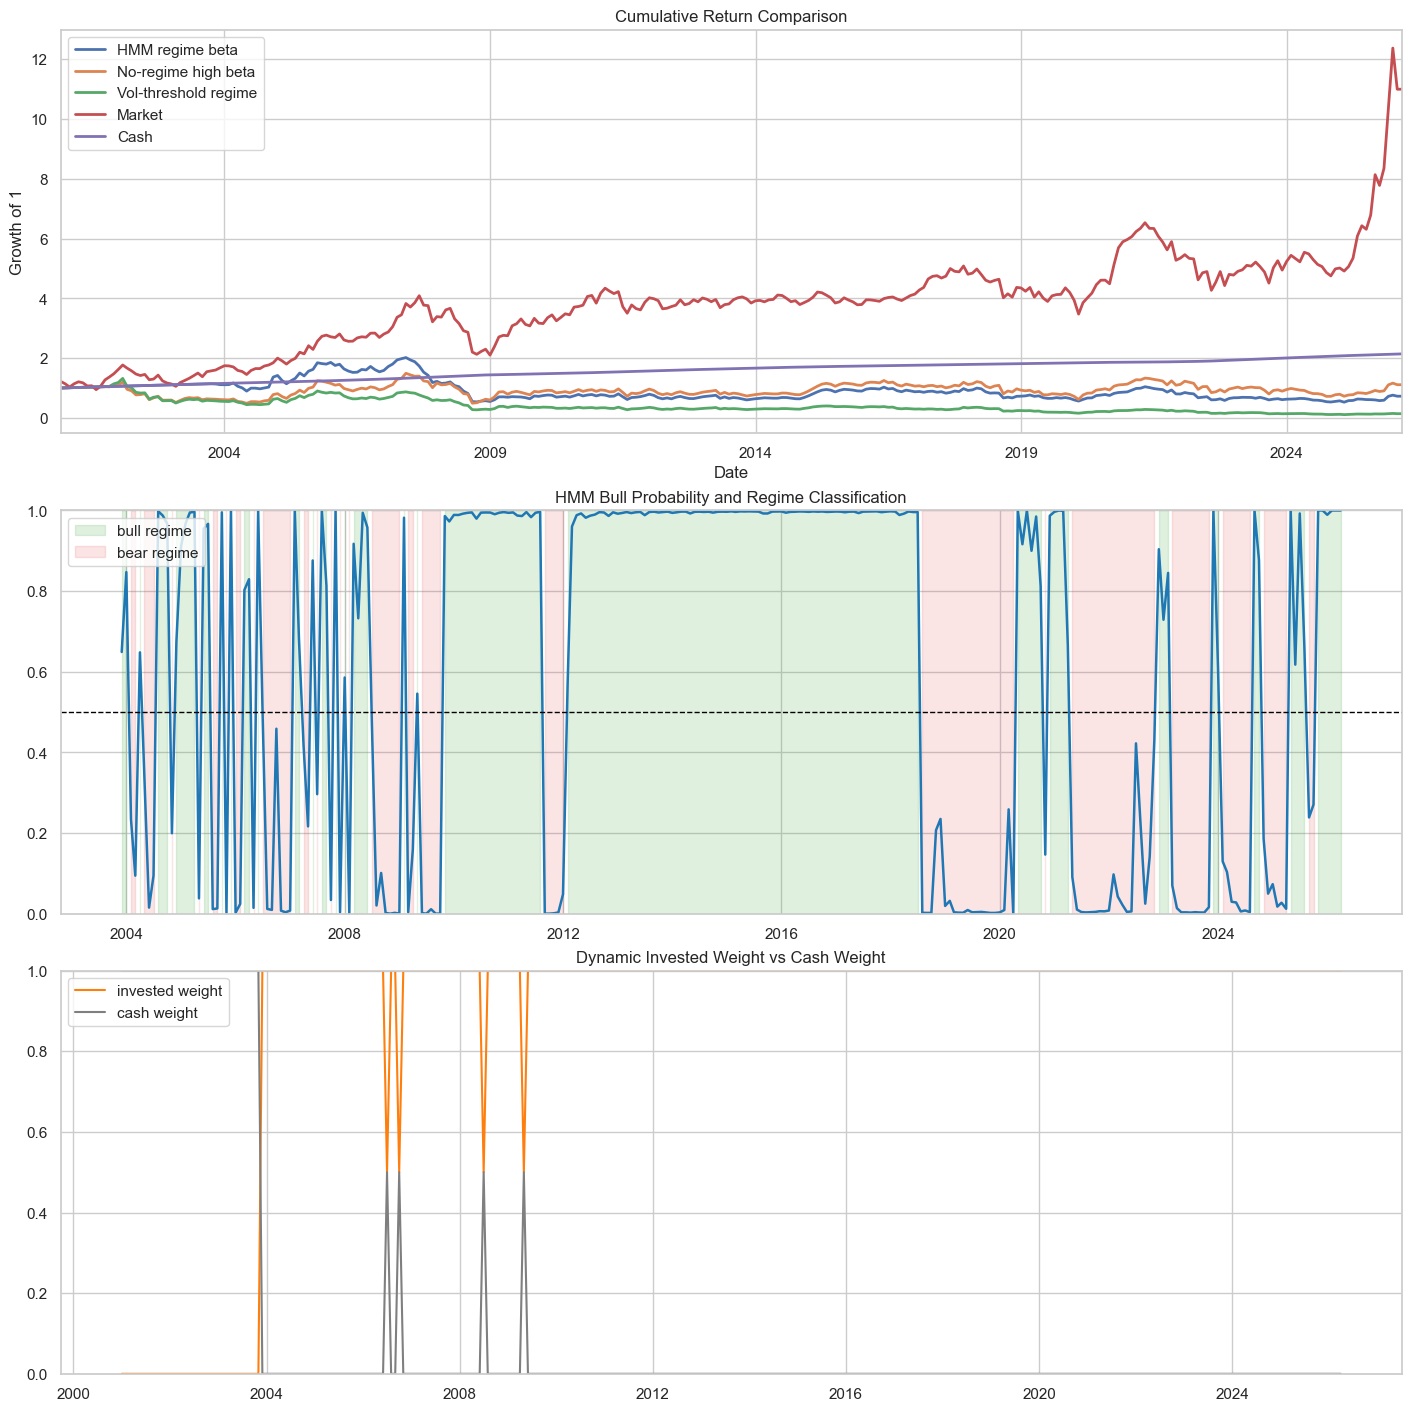

In [8]:
regime_timeline = regimes_hmm["regime"].reindex(main_bt.index)
regime_perf = summarize_by_regime(main_bt["net_return"], regimes_hmm, rf_monthly).T
regime_perf["months"] = regime_timeline.value_counts().reindex(regime_perf.index)

display(regime_perf)

cumulative = pd.DataFrame(
    {
        "HMM regime beta": (1 + main_bt["net_return"].fillna(0.0)).cumprod(),
        "No-regime high beta": (1 + no_regime_bt["net_return"].fillna(0.0)).cumprod(),
        "Vol-threshold regime": (1 + vol_regime_bt["net_return"].fillna(0.0)).cumprod(),
        "Market": (1 + market_benchmark.fillna(0.0)).cumprod(),
        "Cash": (1 + cash_benchmark.fillna(0.0)).cumprod(),
    }
)

fig, axes = plt.subplots(3, 1, figsize=(14, 14), constrained_layout=True)

cumulative.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Cumulative Return Comparison")
axes[0].set_ylabel("Growth of 1")

axes[1].plot(regimes_hmm.index, regimes_hmm["bull_prob"], color="tab:blue", linewidth=1.8)
axes[1].axhline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].fill_between(
    regimes_hmm.index,
    0,
    1,
    where=regimes_hmm["regime"].eq("bull"),
    color="tab:green",
    alpha=0.15,
    label="bull regime",
)
axes[1].fill_between(
    regimes_hmm.index,
    0,
    1,
    where=regimes_hmm["regime"].eq("bear"),
    color="tab:red",
    alpha=0.12,
    label="bear regime",
)
axes[1].set_title("HMM Bull Probability and Regime Classification")
axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper left")

axes[2].plot(main_bt.index, main_bt["invested_weight"], label="invested weight", color="tab:orange")
axes[2].plot(main_bt.index, 1 - main_bt["invested_weight"], label="cash weight", color="tab:gray")
axes[2].set_title("Dynamic Invested Weight vs Cash Weight")
axes[2].set_ylim(0, 1)
axes[2].legend(loc="upper left")

plt.show()


In [9]:
beta_window_results = {}

for window in [6, 12, 24]:
    beta_signal = rolling_beta_parallel(
        stock_excess=stock_excess,
        market_excess=market_excess,
        window=window,
        n_jobs=N_JOBS,
        block_size=BETA_BLOCK_SIZE,
    )
    eligible = (liquidity_rank >= 0.20) & (size_rank >= 0.20) & beta_signal.notna()
    bt, _ = backtest_regime_beta(
        beta_signal=beta_signal,
        fwd_returns=fwd_returns,
        regime_df=regimes_hmm,
        eligible_mask=eligible,
        rf_monthly=rf_monthly,
        market_caps=market_caps,
        selection_pct=SELECTION_PCT,
        ambiguous_band=AMBIGUOUS_BAND,
        partial_invest=PARTIAL_INVEST,
        transaction_cost_bps=TRANSACTION_COST_BPS,
        weighting=WEIGHTING,
        bull_side="high",
        bear_side="low",
    )
    beta_window_results[f"beta_{window}m"] = performance_stats(bt["net_return"], rf_monthly)

beta_window_table = pd.DataFrame(beta_window_results).T

split_date = main_bt.index[int(len(main_bt) * 0.7)]
is_table = pd.DataFrame(
    {
        "in_sample": performance_stats(main_bt.loc[main_bt.index <= split_date, "net_return"], rf_monthly),
        "out_of_sample": performance_stats(main_bt.loc[main_bt.index > split_date, "net_return"], rf_monthly),
    }
).T

display(beta_window_table)
display(is_table)


,cumulative_return,annual_return,annual_volatility,sharpe,mdd
beta_6m,-0.1799,-0.0078,0.2237,-0.0569,-0.7509
beta_12m,-0.2691,-0.0123,0.2177,-0.0848,-0.7374
beta_24m,0.1246,0.0046,0.2195,-0.0048,-0.7435


,cumulative_return,annual_return,annual_volatility,sharpe,mdd
in_sample,-0.1650,-0.0101,0.2192,-0.0874,-0.7328
out_of_sample,-0.1247,-0.0174,0.2153,-0.0782,-0.4929


## ?? ??

- ?? ?? ???? ?? ?? ??? ??? `rolling_beta_parallel()` ??.
- ?? ??? ??? `BETA_BLOCK_SIZE` ??? ??? `ThreadPoolExecutor` ?? ??? ???? ????.
- ???? ?? ???? ?? DataFrame ?? ??? ?? ?? ??? ??? ? ?? ??? ???? ????.
- ?? ??? ??? ????? `SAMPLE_N_COLS = 200` ?? ??? ??? ????? ????.
- ?? ??? `6m / 12m / 24m` ?? ?? ???? ???, ?? ?? ?? ? ???? ?? ????.
